In [367]:
import pandas as pd
df = pd.read_csv("/content/Punjab Stubble data 2018-21_Clean and Processed - Raw Data_18.csv")
df.head()

/tmp/ipykernel_2233/1031227407.py:2: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/Punjab Stubble data 2018-21_Clean and Processed - Raw Data_18.csv")


,Year,District,Block,Satellite,Date,Time (IST),Day / Night,Fire Power(W/m2),Corrected_long,corrected_lat,latlong,Graama,Satellite infrared image reading value indicated stubble burning to the value of
0,2021,Amritsar,Majitha,S-NPP,16-Sep-21,2:06:56 pm,Day,4.8,74.9546,31.7203,74.9546 31.7203,NaN,Satellite infrared image reading value indicat...
1,2021,Amritsar,Tarsikka,S-NPP,16-Sep-21,2:06:56 pm,Day,5.6,75.1281,31.5735,75.1281 31.5735,NaN,Satellite infrared image reading value indicat...
2,2021,PATIALA,PATIALA,S-NPP,18/9/2021,13:29:05,Day,1.8,76.2847,30.2919,76.2847 30.2919,Pasiana,Satellite infrared image reading value indicat...
3,2021,FARIDKOT,KOT KAPURA,S-NPP,18/9/2021,13:29:05,Day,5.4,74.7784,30.5280,74.7784 30.528,Koharwala,Satellite infrared image reading value indicat...
4,2021,AMRITSAR,JANDIALA GURU,S-NPP,18/9/2021,13:29:05,Day,4.3,75.0124,31.6524,75.0124 31.6524,Wila Bajju,Satellite infrared image reading value indicat...


In [368]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270442 entries, 0 to 270441
Data columns (total 13 columns):
 #   Column                                                                             Non-Null Count   Dtype  
---  ------                                                                             --------------   -----  
 0   Year                                                                               270442 non-null  int64  
 1   District                                                                           270442 non-null  object 
 2   Block                                                                              270442 non-null  object 
 3   Satellite                                                                          270442 non-null  object 
 4   Date                                                                               270442 non-null  object 
 5   Time (IST)                                                                         270433 non

In [369]:
df.shape

(270442, 13)

## Dataset Overview (df.info(), df.shape())
# Observation

The dataset contains 270,442 records and 13 features.
It consists of both numerical and categorical variables related to forest fire incidents, including temporal, spatial, and fire intensity information.
Most columns have the correct data types, while the Date and Time (IST) columns required conversion for time-based analysis.

## Insight:
      
The dataset is sufficiently large for identifying meaningful temporal and geographical fire patterns.
Proper data type conversion is essential for extracting month, year, and other time-based insights.

In [370]:
df.isnull().sum()

,0
Year,0
District,0
Block,0
Satellite,0
Date,0
Time (IST),9
Day / Night,0
Fire Power(W/m2),1419
Corrected_long,0
corrected_lat,0


# 2. Missing Value Analysis (df.isnull().sum())
# Observation
Most columns contain no missing values.
Missing values were observed in Time (IST), Fire Power (W/m²), Graama, and Satellite infrared image
# Insight
Since the missing values are limited to a few columns, they can be handled appropriately without significantly affecting the overall analysis.
Essential variables such as District, Block, Date, Latitude, and Longitude remain largely complete.

## Data Cleaning

In [371]:
df=df.drop(columns=['latlong','Satellite infrared image reading value indicated stubble burning to the value of '])
df

,Year,District,Block,Satellite,Date,Time (IST),Day / Night,Fire Power(W/m2),Corrected_long,corrected_lat,Graama
0,2021,Amritsar,Majitha,S-NPP,16-Sep-21,2:06:56 pm,Day,4.8,74.95460,31.72030,NaN
1,2021,Amritsar,Tarsikka,S-NPP,16-Sep-21,2:06:56 pm,Day,5.6,75.12810,31.57350,NaN
2,2021,PATIALA,PATIALA,S-NPP,18/9/2021,13:29:05,Day,1.8,76.28470,30.29190,Pasiana
3,2021,FARIDKOT,KOT KAPURA,S-NPP,18/9/2021,13:29:05,Day,5.4,74.77840,30.52800,Koharwala
4,2021,AMRITSAR,JANDIALA GURU,S-NPP,18/9/2021,13:29:05,Day,4.3,75.01240,31.65240,Wila Bajju
...,...,...,...,...,...,...,...,...,...,...,...
270437,2020,TARN TARAN,PATTI,S-NPP,31-Oct-20,14:06:00,Day,14.1,74.58283,31.33714,Mari Udhoke
270438,2020,TARN TARAN,PATTI,S-NPP,31-Oct-20,12:29:59,Day,9.0,74.61989,31.33733,NaN
270439,2020,TARN TARAN,PATTI,S-NPP,31-Oct-20,12:29:59,Day,5.3,74.74014,31.33853,Dhun
270440,2020,TARN TARAN,PATTI,S-NPP,31-Oct-20,14:06:00,Day,6.4,74.67516,31.38211,NaN


In [372]:
df.District.unique()

array(['Amritsar', 'PATIALA', 'FARIDKOT', 'AMRITSAR', 'TARN TARAN',
       'SANGRUR', 'LUDHIANA', 'FIROZPUR', 'JALANDHAR', 'FAZILKA',
       'KAPURTHALA', 'GURDASPUR', 'MUKTSAR', 'SBS NAGAR',
       'FATEHGARH SAHIB', 'RUPNAGAR', 'SAS NAGAR (MOHALI)', 'MOGA',
       'MANSA', 'BARNALA', 'HOSHIARPUR', 'BATHINDA', 'PATHANKOT',
       'NAWASHAHR', 'SAS NAGAR', 'NAoM. oRf IeTvSenAtRs',
       'No. of\nTARN TARAN'], dtype=object)

In [373]:
df['District']=df['District'].replace({
    'Amritsar':'AMRITSAR',
    'NAoM. oRf IeTvSenAtRs':'AMRITSAR',
    'No. of\nTARN TARAN':'TARN TARAN',
    'SAS NAGAR (MOHALI)':'SAS NAGAR'
})
df.District.unique()

array(['AMRITSAR', 'PATIALA', 'FARIDKOT', 'TARN TARAN', 'SANGRUR',
       'LUDHIANA', 'FIROZPUR', 'JALANDHAR', 'FAZILKA', 'KAPURTHALA',
       'GURDASPUR', 'MUKTSAR', 'SBS NAGAR', 'FATEHGARH SAHIB', 'RUPNAGAR',
       'SAS NAGAR', 'MOGA', 'MANSA', 'BARNALA', 'HOSHIARPUR', 'BATHINDA',
       'PATHANKOT', 'NAWASHAHR'], dtype=object)

In [374]:
df.Block.nunique()

188

In [375]:
df

,Year,District,Block,Satellite,Date,Time (IST),Day / Night,Fire Power(W/m2),Corrected_long,corrected_lat,Graama
0,2021,AMRITSAR,Majitha,S-NPP,16-Sep-21,2:06:56 pm,Day,4.8,74.95460,31.72030,NaN
1,2021,AMRITSAR,Tarsikka,S-NPP,16-Sep-21,2:06:56 pm,Day,5.6,75.12810,31.57350,NaN
2,2021,PATIALA,PATIALA,S-NPP,18/9/2021,13:29:05,Day,1.8,76.28470,30.29190,Pasiana
3,2021,FARIDKOT,KOT KAPURA,S-NPP,18/9/2021,13:29:05,Day,5.4,74.77840,30.52800,Koharwala
4,2021,AMRITSAR,JANDIALA GURU,S-NPP,18/9/2021,13:29:05,Day,4.3,75.01240,31.65240,Wila Bajju
...,...,...,...,...,...,...,...,...,...,...,...
270437,2020,TARN TARAN,PATTI,S-NPP,31-Oct-20,14:06:00,Day,14.1,74.58283,31.33714,Mari Udhoke
270438,2020,TARN TARAN,PATTI,S-NPP,31-Oct-20,12:29:59,Day,9.0,74.61989,31.33733,NaN
270439,2020,TARN TARAN,PATTI,S-NPP,31-Oct-20,12:29:59,Day,5.3,74.74014,31.33853,Dhun
270440,2020,TARN TARAN,PATTI,S-NPP,31-Oct-20,14:06:00,Day,6.4,74.67516,31.38211,NaN


In [376]:
df['Block'] = (
    df['Block']
    .str.upper()
    .str.replace(r'\n+','',regex=True)
    .str.replace(r'\bevents\b','',regex=True)
    .str.replace(r'\s+','',regex=True)
    .str.strip()
)

In [377]:
df['Block'] = df['Block'].replace({
    'ALMOH':'AMLOH',
    'AMRITSARII':'AMRITSAR-2',
    'AMRITSARI':'AMRITSAR-1',
    'CHAMKORSAHIB':'CHAMKAURSAHIB',
    'EVENTSKHADOORSAHIB':'KHADOORSAHIB',
    'KHADURSAHIB':'KHADOORSAHIB',
    'JAITON':'JAITO',
    'JALANDHARI':'JALANDHAR-1',
    'JALANDHARII':'JALANDHAR-2',
    'KHAMANOH':'KHAMANON',
    'MALOUD':'MALOUT',
    'NAWASHAHR':'NAWANSHAHR',
    'NIHALSINGH':'NIHALSINGHWALA',
    'RAMPURA':'RAMPURAPHUL',

})

#Column Value Standardization (Regex & Mapping)

#Observation

The District and Block columns contained inconsistent names due to differences in spelling, formatting, abbreviations, and extra spaces.
Regular expressions (Regex) were used to remove unwanted characters and standardize text formatting.
Mapping was applied to replace inconsistent names with their correct standardized names (e.g., correcting spelling variations).

#Insight

Standardizing categorical values ensures that the same district or block is not treated as multiple categories.
This improves the accuracy of frequency analysis, grouping operations, and visualizations by eliminating inconsistencies in location names.

In [378]:
df.Block.nunique()

165

In [379]:
df.Satellite.unique()

array(['S-NPP', 'AQUA', 'TERRA', 'AQUA-1', 'TERRA-1', 'METOP-1',
       'NOAA-19', 'METOP-2', 'NOAA-18'], dtype=object)

In [380]:
df[df['Time (IST)'].isin(['D', 'N'])]

,Year,District,Block,Satellite,Date,Time (IST),Day / Night,Fire Power(W/m2),Corrected_long,corrected_lat,Graama
176842,2018,NAWASHAHR,NAWANSHAHR,AQUA-1,13:16:59,D,10.82,NaN,76.01996,31.07336,Kamam
176843,2018,NAWASHAHR,NAWANSHAHR,AQUA-1,13:16:59,D,12.86,NaN,76.09158,31.13924,Ramgarh
176844,2018,AMRITSAR,AJNALA,S-NPP,13:48:00,D,6.6,NaN,74.55152,31.75142,Chahia
176845,2018,AMRITSAR,AJNALA,S-NPP,13:48:00,D,1.9,NaN,74.70615,31.79328,Nangal Guru
176846,2018,AMRITSAR,AMRITSAR-1,S-NPP,13:48:00,D,4.4,NaN,75.00913,31.52985,NaN
176847,2018,AMRITSAR,BABABAKALA,S-NPP,13:48:00,D,1.7,NaN,75.33433,31.59024,Moom
176848,2018,BARNALA,BARNALA,S-NPP,13:48:00,D,3.2,NaN,75.47842,30.57053,Joganand
176849,2018,BATHINDA,BATHINDA,S-NPP,13:48:00,D,4.1,NaN,74.96162,30.26024,Maisar Khana
176850,2018,BATHINDA,TALWANDISABO,S-NPP,13:48:00,D,4.9,NaN,75.19448,30.11164,Maisar Khana
176851,2018,BATHINDA,TALWANDISABO,S-NPP,13:48:00,D,4.7,NaN,75.18871,30.11477,Main Majri


In [381]:
df.drop(df[df['Time (IST)'].isin(['D', 'N'])].index, inplace=True)

#Handling Misaligned Rows

#Observation

A few records were found to have misaligned column values, where data shifted across columns, resulting in missing values in the Fire Power (W/m²) column and incorrect placement of values in subsequent columns.

#Insight

Misaligned records can lead to inaccurate analysis and incorrect visualizations. These records were identified and corrected (or removed, if they could not be reliably corrected) to maintain data integrity and ensure accurate analysis.

In [382]:
df['Date'] = pd.to_datetime(df['Date'],format='mixed')
df['Date']

,Date
0,2021-09-16
1,2021-09-16
2,2021-09-18
3,2021-09-18
4,2021-09-18
...,...
270437,2020-10-31
270438,2020-10-31
270439,2020-10-31
270440,2020-10-31


In [383]:
df['Time (IST)'] = pd.to_datetime(df['Time (IST)'], format='mixed', errors='coerce').dt.time
df['Time (IST)']

,Time (IST)
0,14:06:56
1,14:06:56
2,13:29:05
3,13:29:05
4,13:29:05
...,...
270437,14:06:00
270438,12:29:59
270439,12:29:59
270440,14:06:00


# Data Type Conversion
# Observation
The Date column was converted into datetime format.
Time-related information was prepared for extracting year and month.
#Insight
Converting dates into datetime format enables temporal analysis such as yearly and monthly fire trends.

In [384]:
df = df.dropna(subset=['Time (IST)'])

In [385]:
df['Day / Night'].unique()

array(['Day', 'Night'], dtype=object)

In [386]:
df['Fire Power(W/m2)'].isna().sum()

np.int64(1384)

In [387]:
df = df.dropna(subset=['Fire Power(W/m2)'])

In [388]:
df['Graama'] = df['Graama'].fillna('Unknown')

# Missing Value Treatment
# Observation
Rows with missing Fire Power (W/m²) values were removed because fire intensity is a key variable in the analysis.
Columns with excessive missing values and low analytical importance (such as Graama) were removed.
Remaining missing values were handled appropriately to ensure data consistency.
# Insight
Removing unnecessary or highly incomplete data improves data quality and ensures reliable exploratory analysis.
The cleaned dataset is more suitable for visualization and statistical analysis.

##EXPLORATORY DATA ANALYSIS


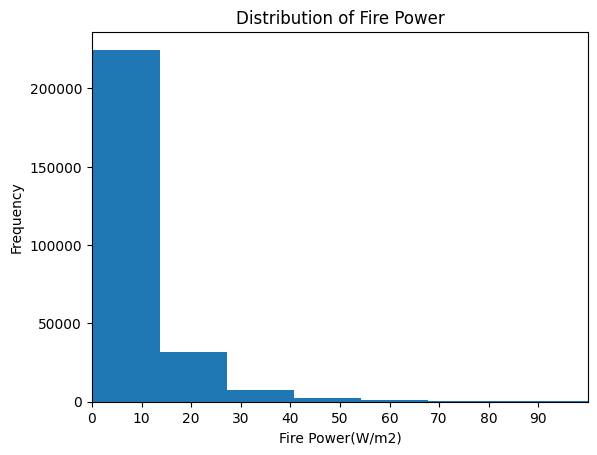

In [389]:
import matplotlib.pyplot as plt
plt.hist(df['Fire Power(W/m2)'], bins=30)
plt.xlim(0,100)
plt.xticks(range(0,100,10))
plt.xlabel('Fire Power(W/m2)')
plt.ylabel('Frequency')
plt.title('Distribution of Fire Power')
plt.show()

#Fire Power Distribution (Histogram)

#Observation:

The fire power distribution is highly right-skewed (positively skewed).
Most fire incidents have low fire power (0–15 W/m²).
The frequency decreases rapidly as fire power increases.
Very high fire power events are rare.

#Insight:

Crop residue burning is predominantly composed of low-intensity fires, while only a small number of incidents exhibit high fire intensity.

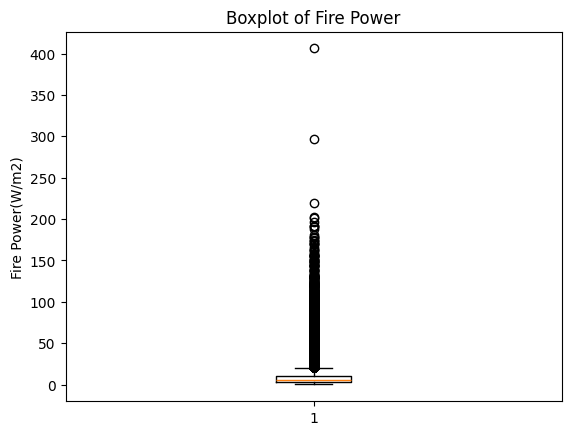

In [390]:
plt.boxplot(df['Fire Power(W/m2)'])
plt.ylabel('Fire Power(W/m2)')
plt.title('Boxplot of Fire Power')
plt.show()

#Fire Power Box Plot

#Observation:

The box plot shows many outliers above the upper whisker.
Most observations are concentrated at low fire power values.
A few fires have extremely high fire power (up to around 400 W/m²).

#Insight:

The dataset contains several extreme fire events. These outliers likely represent unusually intense burning and should be retained for analysis since they are meaningful observations rather than data errors.

<Axes: xlabel='Year'>

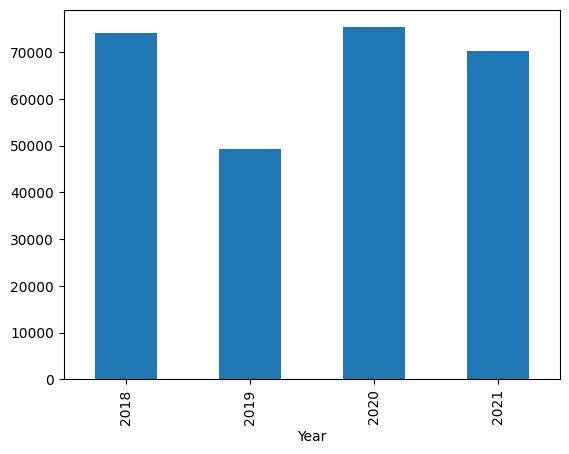

In [391]:
# Fires by Year
df['Year'].value_counts().sort_index().plot(kind='bar')



#Fires by Year

#Observation:

Fire incidents are observed from 2018 to 2021.
2020 recorded the highest number of fire detections.
2019 has the lowest count.
Fire counts increased after 2019 and remained high in 2021.

#Insight:

Fire activity varies across years, with a noticeable peak in 2020, indicating increased stubble-burning activity or improved satellite detection during that period.

In [392]:
# Fires by Month
df['Month'] = df['Date'].dt.month_name()
df['Month'].value_counts()

,count
Month,
November,144510
October,87054
September,5386
July,5271
August,4505
May,4420
June,3984
December,3498
April,3055


#Fires by Month

#Observation:

November has the highest number of fire incidents (144,510).
October is the second highest (87,054).
January–August have comparatively few fire incidents.

#Insight:

Fire occurrences are highly seasonal, with the majority concentrated in October and November, coinciding with the post-harvest stubble-burning period in Punjab.

<Axes: xlabel='Day / Night'>

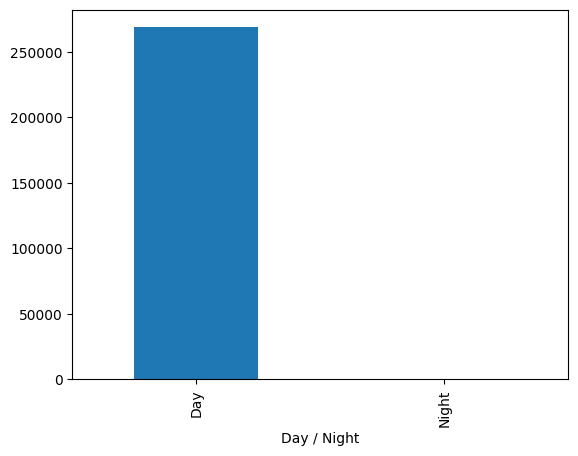

In [393]:

# Day vs Night
df['Day / Night'].value_counts().plot(kind='bar')



#Day vs Night

#Observation:

Almost all fire detections occurred during the day.
Very few or no fire incidents were recorded at night.

#Insight:

Stubble burning is predominantly carried out during daytime, resulting in significantly more daytime detections than nighttime observations.

<Axes: ylabel='District'>

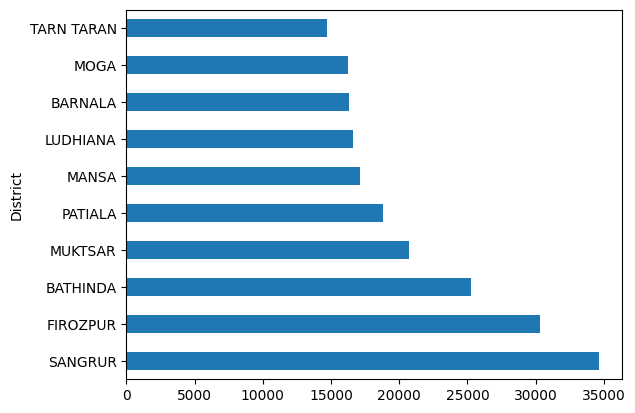

In [394]:
# Top 10 Districts
df['District'].value_counts().head(10).plot(kind='barh')


#Top 10 Districts

#Observation:

Fire incidents are not evenly distributed across Punjab.
A few districts contribute a significantly higher number of fire detections than others.
The top 10 districts account for a major share of the total fire incidents.

#Insight:

These districts are the primary hotspots for stubble burning. Targeted awareness campaigns, stricter monitoring, and enforcement in these regions could substantially reduce overall fire incidents.

<Axes: ylabel='Block'>

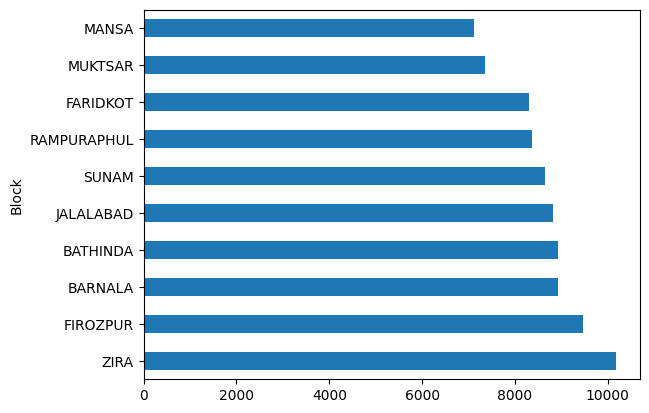

In [395]:
# Top 10 Blocks
df['Block'].value_counts().head(10).plot(kind='barh')

#Top 10 Blocks

#Observation:

Fire occurrences are concentrated within a limited number of blocks.
The top 10 blocks recorded considerably more fire incidents than the remaining blocks.
This indicates a localized concentration of stubble-burning activity.

#Insight:

These blocks can be considered high-risk zones for crop residue burning. Prioritizing these areas for preventive measures, farmer support programs, and satellite monitoring would have the greatest impact on reducing fire events.

#Data Insights & Storytelling
#Key Insights
Fire incidents are highly seasonal, with October and November contributing the majority of cases.
Fire activity peaked in 2020 compared to other years.
Most fires are low-intensity, while extreme fire events are uncommon.
Fire detections are predominantly recorded during daytime.
Fire incidents are concentrated in a limited number of districts, indicating regional hotspots.
#Business/Policy Story

The analysis reveals that stubble burning in Punjab is not uniformly distributed across time or geography. Instead, it is concentrated during the post-harvest months of October and November and in specific districts. Since most fires are of low intensity but occur in large numbers, preventive measures should focus on reducing the frequency of burning rather than only responding to severe incidents. Authorities can prioritize hotspot districts during the peak burning season, optimize satellite monitoring, and promote crop residue management practices among farmers to reduce environmental and public health impacts.

##Final Conclusion

This exploratory data analysis successfully identified the temporal, spatial, and intensity patterns of stubble burning in Punjab. The findings show that fire activity is seasonal, geographically concentrated, and largely consists of low-intensity events. These insights can support data-driven decision-making for monitoring, resource allocation, and policy interventions aimed at reducing crop residue burning.